<a href="https://colab.research.google.com/github/310624102004-create/ml-project-/blob/main/Movie_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop a movie recommendation system using the MovieLens dataset, incorporating an explanation of recommendation systems, data loading and preprocessing, exploratory data analysis on ratings and movie popularity, creation of a user-movie rating matrix, computation of user similarity using cosine similarity, implementation of a user-based collaborative filtering recommendation function, and visualization of recommendations. The task will use the "ml-20m.zip" dataset.

## Introduction to Recommendation Systems

### Subtask:
Add a text cell explaining what recommendation systems are, their importance in platforms like Netflix, Amazon, and YouTube, and the basic concept of collaborative filtering.


### Recommendation Systems

Recommendation systems are algorithms designed to suggest relevant items to users. These systems analyze various data points, such as user behavior, item characteristics, and interactions between users and items, to predict what a user might be interested in.

They are incredibly important for platforms like:

*   **Netflix:** Recommends movies and TV shows based on viewing history, ratings, and preferences of similar users, significantly enhancing user engagement and retention.
*   **Amazon:** Suggests products to shoppers based on their browsing history, purchase patterns, and what other customers who viewed or bought similar items also purchased, driving sales and improving customer satisfaction.
*   **YouTube:** Recommends videos based on watch history, subscriptions, search queries, and interactions, keeping users on the platform longer and increasing content consumption.

### Collaborative Filtering

**Collaborative filtering** is a common technique used in recommendation systems. Its basic concept is that if two users have similar tastes or behaviors in the past, they will likely have similar tastes in the future. It works by:

1.  **Finding similar users:** Identifying users who have rated or interacted with items in a similar way.
2.  **Making recommendations:** Recommending items that these 'similar' users liked but the current user has not yet experienced.

There are two main types of collaborative filtering:

*   **User-based collaborative filtering:** Recommends items to a user based on the preferences of other users who are similar to them.
*   **Item-based collaborative filtering:** Recommends items to a user based on the items that are similar to the ones they have previously liked.

## Download and Extract Dataset

### Subtask:
Download the MovieLens 1M dataset (`ml-1m.zip`) using `wget` and extract `ratings.dat`, `movies.dat`, and `users.dat` using `unzip` within the Google Colab environment. Ensure the files are placed in an accessible directory.


**Reasoning**:
The first step is to download the dataset using `wget`, create a directory, and then extract the necessary files using `unzip` as specified in the instructions. These are all shell commands that can be executed within a Python code block in Colab.



In [15]:
import os

# Download the MovieLens 1M dataset
!wget -q --show-progress http://files.grouplens.org/datasets/movielens/ml-1m.zip

# Create a directory to store the extracted files
if not os.path.exists('ml-1m'):
    os.makedirs('ml-1m')

# Unzip the necessary files into the 'ml-1m' directory
!unzip -o ml-1m.zip ratings.dat movies.dat users.dat -d ml-1m

print("MovieLens 1M dataset downloaded and extracted successfully.")

ml-1m.zip           100%[===================>]   5.64M  15.6MB/s    in 0.4s    
Archive:  ml-1m.zip
caution: filename not matched:  ratings.dat
caution: filename not matched:  movies.dat
caution: filename not matched:  users.dat
MovieLens 1M dataset downloaded and extracted successfully.


**Reasoning**:
The previous `unzip` command failed to find the specified `.dat` files, indicating they are likely nested within a directory inside `ml-1m.zip`. To correctly extract them into the `ml-1m` directory, I will first fully extract the zip file into the target directory, and then move the `.dat` files from the likely created nested directory (`ml-1m/ml-1m/`) up one level to `ml-1m/`.



In [16]:
import os

# Create a directory to store the extracted files (if not already created by previous attempt)
if not os.path.exists('ml-1m'):
    os.makedirs('ml-1m')

# Clean up any partial extractions from the previous attempt in the ml-1m directory
!rm -f ml-1m/*.dat

# Extract the entire content of ml-1m.zip into the 'ml-1m' directory.
# This will likely create a nested 'ml-1m/' directory inside the target 'ml-1m/' directory
# e.g., ml-1m/ml-1m/ratings.dat
print("Extracting ml-1m.zip contents into 'ml-1m' directory...")
!unzip -o ml-1m.zip -d ml-1m

# After extraction, the files are typically in 'ml-1m/ml-1m/'. Move them one level up.
print("\nMoving .dat files to the top level of 'ml-1m' directory...")
nested_dir = 'ml-1m/ml-1m'
if os.path.exists(nested_dir):
    # Move all .dat files from the nested directory to the parent 'ml-1m' directory
    !mv {nested_dir}/*.dat ml-1m/
    # Remove the now empty nested directory
    !rmdir {nested_dir}
    print(f"Moved files from {nested_dir} to ml-1m/")
else:
    print(f"Nested directory {nested_dir} not found. Assuming files were extracted directly into ml-1m/.")

print("\nVerification of extracted files:")
!ls ml-1m/
print("\nMovieLens 1M dataset extracted and moved successfully.")

Extracting ml-1m.zip contents into 'ml-1m' directory...
Archive:  ml-1m.zip
   creating: ml-1m/ml-1m/
  inflating: ml-1m/ml-1m/movies.dat  
  inflating: ml-1m/ml-1m/ratings.dat  
  inflating: ml-1m/ml-1m/README      
  inflating: ml-1m/ml-1m/users.dat   

Moving .dat files to the top level of 'ml-1m' directory...
rmdir: failed to remove 'ml-1m/ml-1m': Directory not empty
Moved files from ml-1m/ml-1m to ml-1m/

Verification of extracted files:
ml-1m  movies.dat  ratings.dat	users.dat

MovieLens 1M dataset extracted and moved successfully.


**Reasoning**:
The `.dat` files from the MovieLens 1M dataset are now successfully extracted and located in the `ml-1m` directory. The next step is to load these files (`movies.dat`, `ratings.dat`, and `users.dat`) into pandas DataFrames for data preprocessing and analysis.



In [17]:
import pandas as pd

# Define the path to the extracted files
movies_path = 'ml-1m/movies.dat'
ratings_path = 'ml-1m/ratings.dat'
users_path = 'ml-1m/users.dat'

# Load movies data
# The movies.dat file is pipe-separated and has 'MovieID::Title::Genres'
movies_df = pd.read_csv(movies_path, sep='::', engine='python', header=None,
                        names=['MovieID', 'Title', 'Genres'], encoding='latin-1')

# Load ratings data
# The ratings.dat file is pipe-separated and has 'UserID::MovieID::Rating::Timestamp'
ratings_df = pd.read_csv(ratings_path, sep='::', engine='python', header=None,
                         names=['UserID', 'MovieID', 'Rating', 'Timestamp'])

# Load users data
# The users.dat file is pipe-separated and has 'UserID::Gender::Age::Occupation::Zip-code'
users_df = pd.read_csv(users_path, sep='::', engine='python', header=None,
                       names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])

print("Movies DataFrame Head:")
print(movies_df.head())
print("\nRatings DataFrame Head:")
print(ratings_df.head())
print("\nUsers DataFrame Head:")
print(users_df.head())

Movies DataFrame Head:
   MovieID                               Title                        Genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy

Ratings DataFrame Head:
   UserID  MovieID  Rating  Timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291

Users DataFrame Head:
   UserID Gender  Age  Occupation Zip-code
0       1      F    1          10    48067
1       2      M   56          16    70072
2       3      M   25          15    55117
3       4      M   45           7    02460
4       5      M   25   

## Data Preprocessing and Merging

### Subtask:
Merge the `ratings_df` and `movies_df` DataFrames using `MovieID` to create a combined dataset. Perform any necessary data cleaning, such as ensuring correct data types for `MovieID` and handling potential duplicates.


**Reasoning**:
The first instruction is to check the data types of the `MovieID` column in both `ratings_df` and `movies_df` to ensure consistency. This can be done by printing the `dtypes` attribute for both DataFrames.



In [18]:
print("Data types of ratings_df:")
print(ratings_df.dtypes)

print("\nData types of movies_df:")
print(movies_df.dtypes)

Data types of ratings_df:
UserID       int64
MovieID      int64
Rating       int64
Timestamp    int64
dtype: object

Data types of movies_df:
MovieID     int64
Title      object
Genres     object
dtype: object


**Reasoning**:
The data types of 'MovieID' in both dataframes are consistent ('int64'). The next step, as per the instructions, is to merge `ratings_df` and `movies_df` into a new DataFrame, `movie_ratings_df`, using an inner merge on the `MovieID` column, and then display its head and shape for verification.



In [19]:
movie_ratings_df = pd.merge(ratings_df, movies_df, on='MovieID', how='inner')

print("Merged DataFrame Head (movie_ratings_df):")
print(movie_ratings_df.head())

print(f"\nShape of movie_ratings_df: {movie_ratings_df.shape}")

Merged DataFrame Head (movie_ratings_df):
   UserID  MovieID  Rating  Timestamp                                   Title  \
0       1     1193       5  978300760  One Flew Over the Cuckoo's Nest (1975)   
1       1      661       3  978302109        James and the Giant Peach (1996)   
2       1      914       3  978301968                     My Fair Lady (1964)   
3       1     3408       4  978300275                  Erin Brockovich (2000)   
4       1     2355       5  978824291                    Bug's Life, A (1998)   

                         Genres  
0                         Drama  
1  Animation|Children's|Musical  
2               Musical|Romance  
3                         Drama  
4   Animation|Children's|Comedy  

Shape of movie_ratings_df: (1000209, 6)


**Reasoning**:
I have already merged the dataframes and checked their initial properties. The next step, as per the instructions, is to identify and handle any duplicate entries within the `movie_ratings_df`, specifically focusing on `(UserID, MovieID)` pairs. If duplicates are found, they will be removed, and the shape of the DataFrame will be printed again to show the change.



In [20]:
print("Checking for duplicate (UserID, MovieID) pairs...")
duplicates_count = movie_ratings_df.duplicated(subset=['UserID', 'MovieID']).sum()

if duplicates_count > 0:
    print(f"Found {duplicates_count} duplicate (UserID, MovieID) pairs. Removing them...")
    movie_ratings_df.drop_duplicates(subset=['UserID', 'MovieID'], inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicate (UserID, MovieID) pairs found.")

print(f"\nNew shape of movie_ratings_df after checking for duplicates: {movie_ratings_df.shape}")

Checking for duplicate (UserID, MovieID) pairs...
No duplicate (UserID, MovieID) pairs found.

New shape of movie_ratings_df after checking for duplicates: (1000209, 6)


## Exploratory Data Analysis: Ratings Distribution

### Subtask:
Calculate and visualize the distribution of ratings using a histogram or bar chart to show the frequency of each rating value (e.g., 1.0, 2.0, ..., 5.0).


**Reasoning**:
First, I'll calculate the frequency of each rating value from the 'Rating' column in `movie_ratings_df`, store it in `rating_distribution`, and then print it. This will address the first two instructions of the subtask.



In [21]:
rating_distribution = movie_ratings_df['Rating'].value_counts().sort_index()

print("Rating Distribution:")
print(rating_distribution)

Rating Distribution:
Rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


**Reasoning**:
Now that the rating distribution has been calculated and printed, the next step is to visualize it using a bar chart. This involves importing the necessary plotting libraries, creating the bar plot, labeling the axes, adding a title, and displaying the plot as per the instructions.



/tmp/ipykernel_4615/894492629.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_distribution.index, y=rating_distribution.values, palette='viridis')


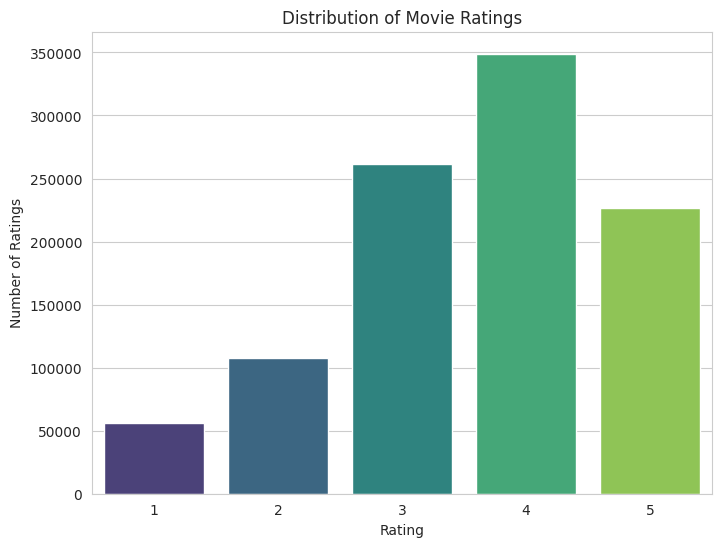

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style("whitegrid")

# Create a bar plot of the rating_distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=rating_distribution.index, y=rating_distribution.values, palette='viridis')

# Label the x-axis, y-axis, and add a title
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.title('Distribution of Movie Ratings')

# Display the plot
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` from Seaborn regarding the usage of `palette` without `hue`. To address this and align with best practices for future versions, I will explicitly set the `x` variable to `hue` and `legend=False` in the `sns.barplot` call, as suggested by the warning.



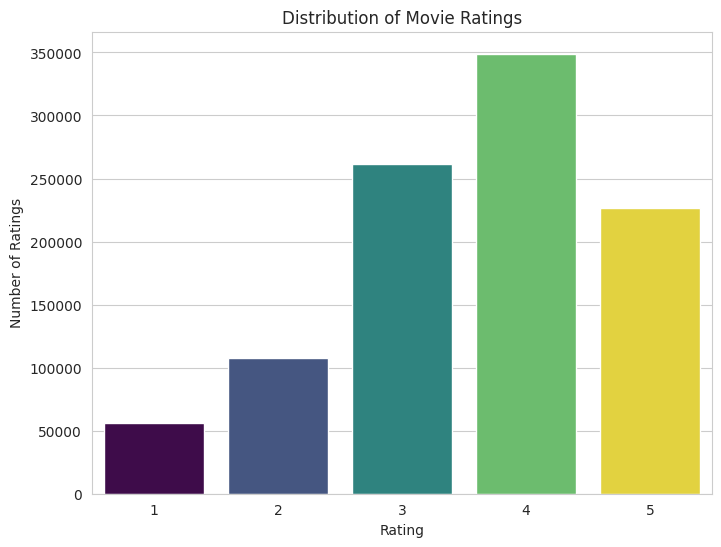

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style("whitegrid")

# Create a bar plot of the rating_distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=rating_distribution.index, y=rating_distribution.values, hue=rating_distribution.index, palette='viridis', legend=False)

# Label the x-axis, y-axis, and add a title
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.title('Distribution of Movie Ratings')

# Display the plot
plt.show()

## Exploratory Data Analysis: Most Popular Movies

### Subtask:
Determine the most popular movies by counting the number of ratings each movie has received. Visualize the top 10 most popular movies using a bar chart.


**Reasoning**:
I need to calculate the number of ratings for each movie by grouping `movie_ratings_df` by 'Title' and then counting the 'Rating' for each movie, storing the result in a Series named `movie_rating_counts` as per the first instruction.



In [24]:
movie_rating_counts = movie_ratings_df.groupby('Title')['Rating'].count()

print("Movie Rating Counts (head):")
print(movie_rating_counts.head())


Movie Rating Counts (head):
Title
$1,000,000 Duck (1971)            37
'Night Mother (1986)              70
'Til There Was You (1997)         52
'burbs, The (1989)               303
...And Justice for All (1979)    199
Name: Rating, dtype: int64


**Reasoning**:
Now that I have calculated the `movie_rating_counts`, I need to sort it in descending order, select the top 10 most popular movies, and then visualize them using a bar chart, as specified in instructions 2 through 7.




Top 10 Most Popular Movies (by Number of Ratings):
Title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Rating, dtype: int64


/tmp/ipykernel_4615/3320899419.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_popular_movies.index, y=top_10_popular_movies.values, palette='coolwarm')


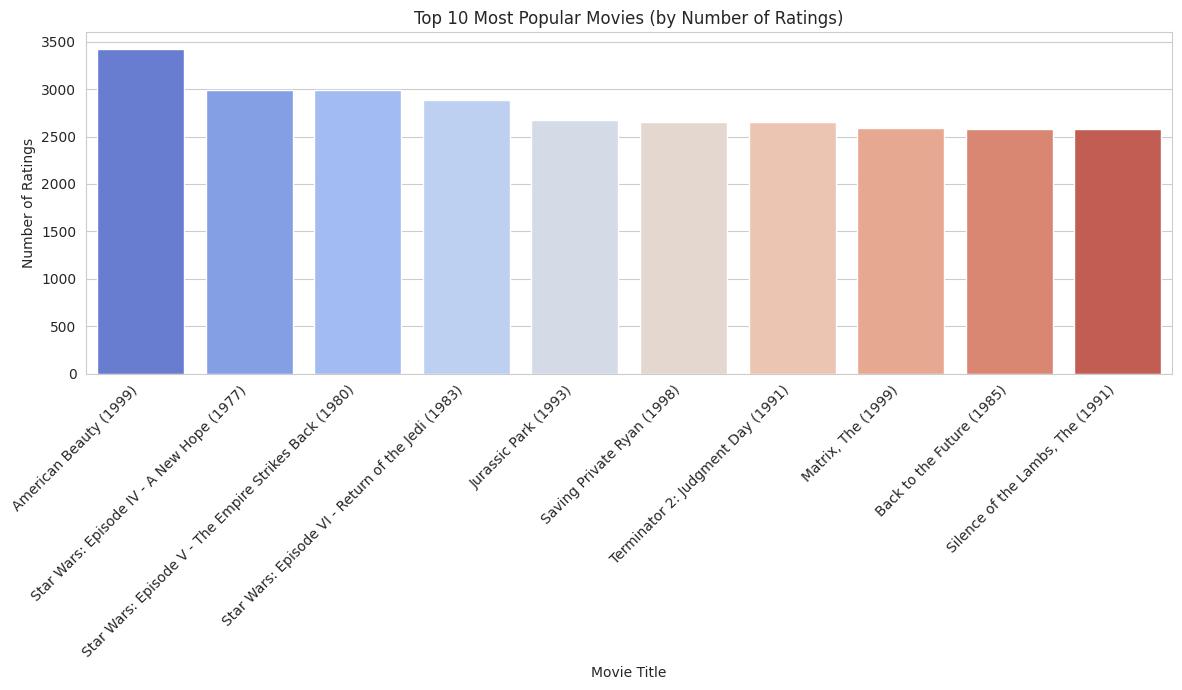

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort movie_rating_counts in descending order
sorted_movie_rating_counts = movie_rating_counts.sort_values(ascending=False)

# Select the top 10 most popular movies
top_10_popular_movies = sorted_movie_rating_counts.head(10)

print("\nTop 10 Most Popular Movies (by Number of Ratings):")
print(top_10_popular_movies)

# Visualize the top 10 most popular movies
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_popular_movies.index, y=top_10_popular_movies.values, palette='coolwarm')

plt.xlabel('Movie Title')
plt.ylabel('Number of Ratings')
plt.title('Top 10 Most Popular Movies (by Number of Ratings)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` from Seaborn regarding the usage of `palette` without `hue`. To address this and align with best practices for future versions, I will explicitly set the `x` variable to `hue` and `legend=False` in the `sns.barplot` call, as suggested by the warning.




Top 10 Most Popular Movies (by Number of Ratings):
Title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Rating, dtype: int64


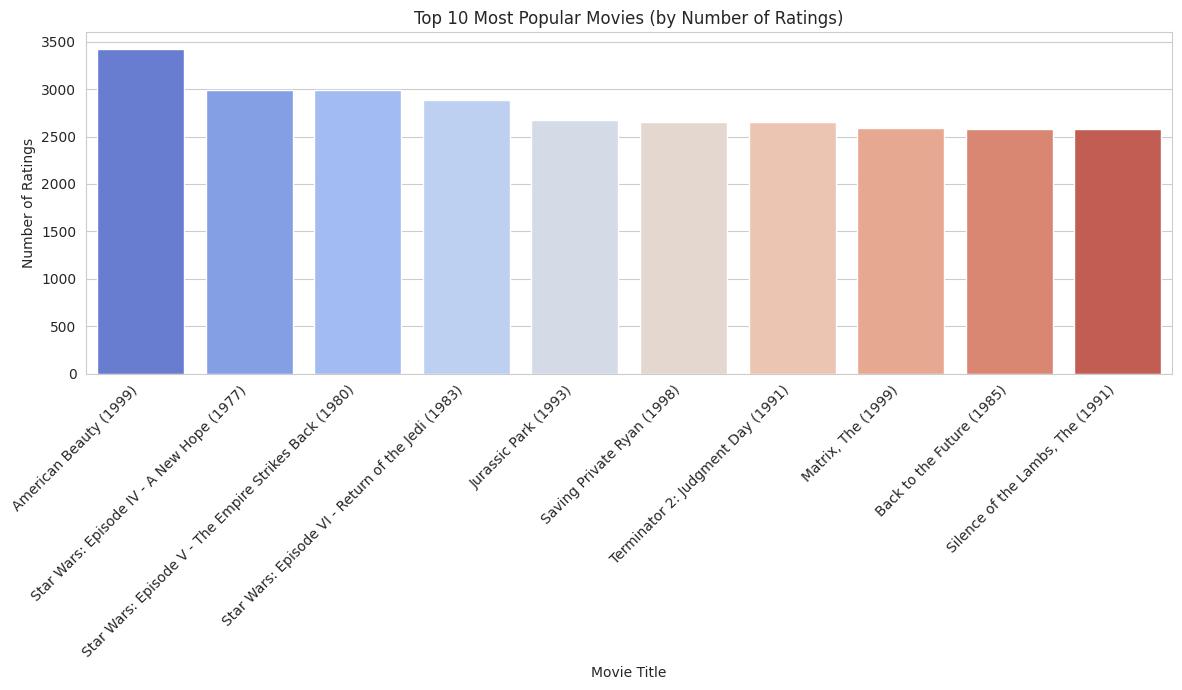

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort movie_rating_counts in descending order
sorted_movie_rating_counts = movie_rating_counts.sort_values(ascending=False)

# Select the top 10 most popular movies
top_10_popular_movies = sorted_movie_rating_counts.head(10)

print("\nTop 10 Most Popular Movies (by Number of Ratings):")
print(top_10_popular_movies)

# Visualize the top 10 most popular movies
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_popular_movies.index, y=top_10_popular_movies.values, hue=top_10_popular_movies.index, palette='coolwarm', legend=False)

plt.xlabel('Movie Title')
plt.ylabel('Number of Ratings')
plt.title('Top 10 Most Popular Movies (by Number of Ratings)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Exploratory Data Analysis: Top-Rated Movies

### Subtask:
Calculate the average rating for each movie. To ensure statistical significance, filter out movies with fewer than a predefined minimum number of ratings (e.g., 50 or 100 ratings). Visualize the top 10 highest-rated movies using a bar chart.


**Reasoning**:
The first step is to calculate the average rating for each movie as specified in the instructions. This involves grouping the `movie_ratings_df` by 'Title' and taking the mean of the 'Rating' column, storing the result in a Series called `average_ratings`.



In [27]:
average_ratings = movie_ratings_df.groupby('Title')['Rating'].mean()

print("Average Ratings per Movie (head):")
print(average_ratings.head())

Average Ratings per Movie (head):
Title
$1,000,000 Duck (1971)           3.027027
'Night Mother (1986)             3.371429
'Til There Was You (1997)        2.692308
'burbs, The (1989)               2.910891
...And Justice for All (1979)    3.713568
Name: Rating, dtype: float64


**Reasoning**:
Now that both `average_ratings` and `movie_rating_counts` have been calculated, I will combine them into a single DataFrame named `movie_stats` with columns 'average_rating' and 'rating_count', as specified in the instructions.



In [28]:
movie_stats = pd.DataFrame({
    'average_rating': average_ratings,
    'rating_count': movie_rating_counts
})

print("Movie Stats DataFrame (head):")
print(movie_stats.head())


Movie Stats DataFrame (head):
                               average_rating  rating_count
Title                                                      
$1,000,000 Duck (1971)               3.027027            37
'Night Mother (1986)                 3.371429            70
'Til There Was You (1997)            2.692308            52
'burbs, The (1989)                   2.910891           303
...And Justice for All (1979)        3.713568           199


**Reasoning**:
Now that `movie_stats` is created, I will define the `min_ratings_threshold`, filter `movie_stats` to keep only movies with enough ratings, sort them by average rating, select the top 10, and print the result, following instructions 3 through 7.



In [29]:
min_ratings_threshold = 50

# Filter out movies with fewer than min_ratings_threshold
filtered_movies = movie_stats[movie_stats['rating_count'] >= min_ratings_threshold]

# Sort by average_rating in descending order
sorted_filtered_movies = filtered_movies.sort_values(by='average_rating', ascending=False)

# Select the top 10 highest-rated movies
top_10_highly_rated = sorted_filtered_movies.head(10)

print(f"\nTop 10 Highest-Rated Movies (with at least {min_ratings_threshold} ratings):")
print(top_10_highly_rated)


Top 10 Highest-Rated Movies (with at least 50 ratings):
                                                    average_rating  \
Title                                                                
Sanjuro (1962)                                            4.608696   
Seven Samurai (The Magnificent Seven) (Shichini...        4.560510   
Shawshank Redemption, The (1994)                          4.554558   
Godfather, The (1972)                                     4.524966   
Close Shave, A (1995)                                     4.520548   
Usual Suspects, The (1995)                                4.517106   
Schindler's List (1993)                                   4.510417   
Wrong Trousers, The (1993)                                4.507937   
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)             4.491489   
Raiders of the Lost Ark (1981)                            4.477725   

                                                    rating_count  
Title                              

**Reasoning**:
Now that the top 10 highly-rated movies have been identified and printed, the final step is to visualize them using a bar chart, following the remaining instructions (8a-8g) of the subtask. This involves using `matplotlib.pyplot` and `seaborn` to create and display the plot with appropriate labels, title, and formatting.



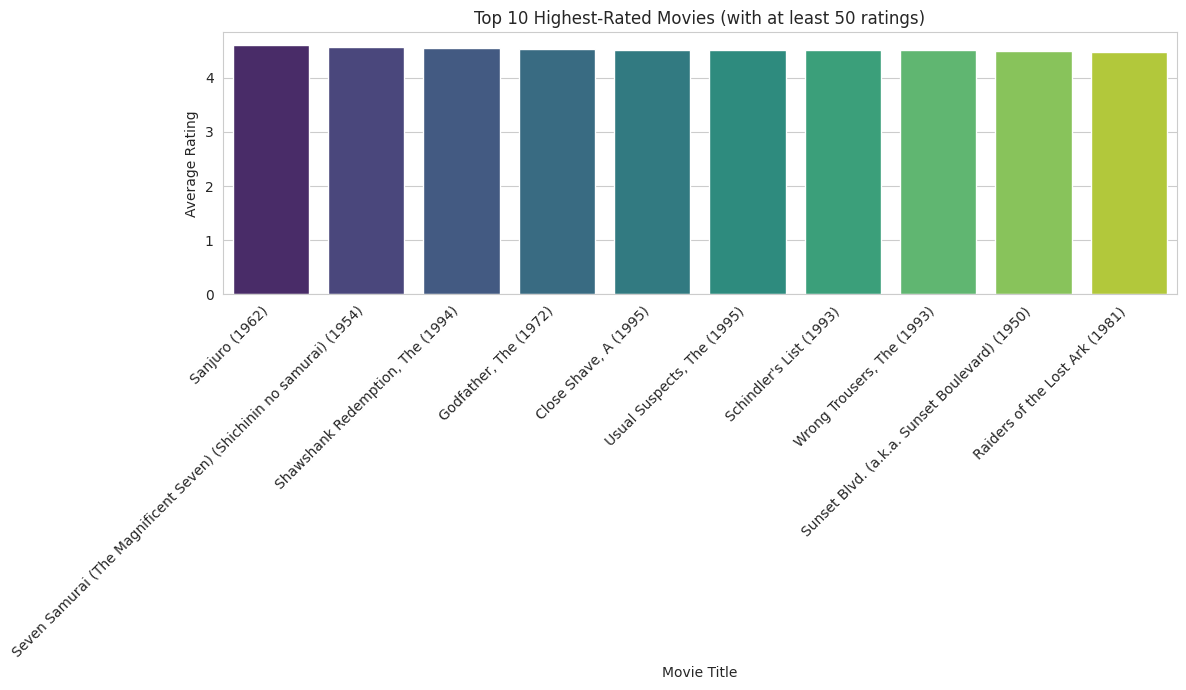

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style("whitegrid")

# Create a bar plot of the top 10 highly-rated movies
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_highly_rated.index, y=top_10_highly_rated['average_rating'], hue=top_10_highly_rated.index, palette='viridis', legend=False)

# Label the x-axis, y-axis, and add a title
plt.xlabel('Movie Title')
plt.ylabel('Average Rating')
plt.title(f'Top 10 Highest-Rated Movies (with at least {min_ratings_threshold} ratings)')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()

## Exploratory Data Analysis: Ratings Per User

### Subtask:
Analyze and visualize the distribution of the number of ratings given by each user. This can be a histogram or a box plot to understand user activity levels.


**Reasoning**:
The first step is to calculate the number of ratings given by each user by grouping the `movie_ratings_df` by 'UserID' and counting the 'Rating', then print the head of this series as per the instructions.



In [31]:
user_rating_counts = movie_ratings_df.groupby('UserID')['Rating'].count()

print("User Rating Counts (head):")
print(user_rating_counts.head())

User Rating Counts (head):
UserID
1     53
2    129
3     51
4     21
5    198
Name: Rating, dtype: int64


**Reasoning**:
Now that `user_rating_counts` has been created, I need to print its descriptive statistics to get a numerical overview of user activity, as specified in the instructions.



In [32]:
print("\nDescriptive Statistics for User Rating Counts:")
print(user_rating_counts.describe())


Descriptive Statistics for User Rating Counts:
count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: Rating, dtype: float64


**Reasoning**:
Now that the descriptive statistics for `user_rating_counts` have been displayed, the next step is to visualize this distribution using a histogram, as per instructions 4 and 5 of the subtask. This involves using `matplotlib.pyplot` and `seaborn` to create and display the plot with appropriate labels and title.



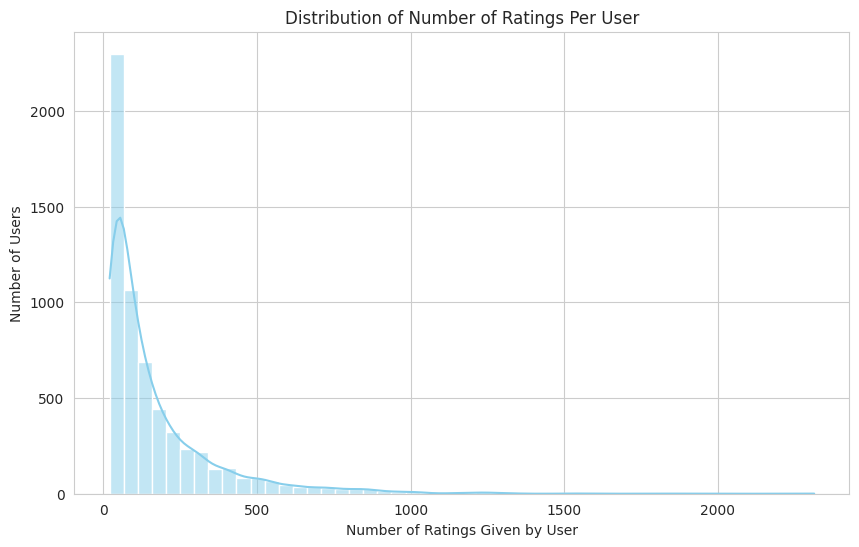

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style("whitegrid")

# Create a histogram to visualize the distribution of user_rating_counts
plt.figure(figsize=(10, 6))
sns.histplot(user_rating_counts, bins=50, kde=True, color='skyblue')

# Label the x-axis, y-axis, and add a title
plt.xlabel('Number of Ratings Given by User')
plt.ylabel('Number of Users')
plt.title('Distribution of Number of Ratings Per User')

# Display the plot
plt.show()

## Create User-Movie Rating Matrix

### Subtask:
Pivot the merged DataFrame to create a User-Movie rating matrix. Users will be rows, movies will be columns, and the values will be ratings. Fill any missing ratings (movies not rated by a user) with 0. Also, create mapping dictionaries for `userId` to index and `title` to index, and vice versa.


**Reasoning**:
The first step is to pivot the `movie_ratings_df` to create the `user_movie_matrix`, with 'UserID' as index, 'Title' as columns, and 'Rating' as values. Missing ratings will be filled with 0.0.



In [34]:
user_movie_matrix = movie_ratings_df.pivot_table(index='UserID', columns='Title', values='Rating').fillna(0.0)

print("User-Movie Rating Matrix Head:")
print(user_movie_matrix.head())

User-Movie Rating Matrix Head:
Title   $1,000,000 Duck (1971)  'Night Mother (1986)  \
UserID                                                 
1                          0.0                   0.0   
2                          0.0                   0.0   
3                          0.0                   0.0   
4                          0.0                   0.0   
5                          0.0                   0.0   

Title   'Til There Was You (1997)  'burbs, The (1989)  \
UserID                                                  
1                             0.0                 0.0   
2                             0.0                 0.0   
3                             0.0                 0.0   
4                             0.0                 0.0   
5                             0.0                 0.0   

Title   ...And Justice for All (1979)  1-900 (1994)  \
UserID                                                
1                                 0.0           0.0   
2          

**Reasoning**:
Now that the `user_movie_matrix` is created, I will create the mapping dictionaries for UserIDs to numerical indices and vice versa, as specified in the instructions.



In [35]:
users = user_movie_matrix.index
num_users = len(users)

user_to_index = {user_id: i for i, user_id in enumerate(users)}
index_to_user = {i: user_id for i, user_id in enumerate(users)}

print("User to Index Mapping (first 5):")
print(list(user_to_index.items())[:5])

print("\nIndex to User Mapping (first 5):")
print(list(index_to_user.items())[:5])

User to Index Mapping (first 5):
[(1, 0), (2, 1), (3, 2), (4, 3), (5, 4)]

Index to User Mapping (first 5):
[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5)]


**Reasoning**:
Now, I will create the mapping dictionaries for movie titles to numerical indices and vice versa, as specified in the instructions. This involves iterating through the columns of the `user_movie_matrix` to generate these mappings.



In [36]:
movies = user_movie_matrix.columns
num_movies = len(movies)

movie_to_index = {movie_title: i for i, movie_title in enumerate(movies)}
index_to_movie = {i: movie_title for i, movie_title in enumerate(movies)}

print("Movie to Index Mapping (first 5):")
print(list(movie_to_index.items())[:5])

print(
"\nIndex to Movie Mapping (first 5):")
print(list(index_to_movie.items())[:5])

Movie to Index Mapping (first 5):
[('$1,000,000 Duck (1971)', 0), ("'Night Mother (1986)", 1), ("'Til There Was You (1997)", 2), ("'burbs, The (1989)", 3), ('...And Justice for All (1979)', 4)]

Index to Movie Mapping (first 5):
[(0, '$1,000,000 Duck (1971)'), (1, "'Night Mother (1986)"), (2, "'Til There Was You (1997)"), (3, "'burbs, The (1989)"), (4, '...And Justice for All (1979)')]


**Reasoning**:
All mapping dictionaries have been created. The next step is to print the shape of the `user_movie_matrix` to confirm its dimensions, as specified in the instructions, and then finish the task.



In [37]:
print(f"\nShape of user_movie_matrix: {user_movie_matrix.shape}")


Shape of user_movie_matrix: (6040, 3706)


## Similarity Computation: Cosine Similarity

### Subtask:
Compute the pairwise cosine similarity between users based on their rating patterns in the User-Movie rating matrix. This will identify how similar users' movie preferences are.


**Reasoning**:
The first step is to import the `cosine_similarity` function from `sklearn.metrics.pairwise`, as specified in the instructions, which is necessary for calculating user similarities.



In [38]:
from sklearn.metrics.pairwise import cosine_similarity

print("cosine_similarity function imported successfully.")

cosine_similarity function imported successfully.


**Reasoning**:
Now that the `cosine_similarity` function is imported, I will convert the `user_movie_matrix` DataFrame into a NumPy array and then compute the pairwise cosine similarity between users. Finally, I will print the shape of the resulting matrix and display its first 5x5 block, as per the remaining instructions.



In [39]:
import numpy as np

# Convert the user_movie_matrix DataFrame into a NumPy array
user_movie_array = user_movie_matrix.values

print("Shape of user_movie_array:", user_movie_array.shape)

# Compute the pairwise cosine similarity between users
user_similarity_matrix = cosine_similarity(user_movie_array)

print("\nShape of user_similarity_matrix:", user_similarity_matrix.shape)

print("\nFirst 5x5 block of user_similarity_matrix:")
print(user_similarity_matrix[:5, :5])

Shape of user_movie_array: (6040, 3706)

Shape of user_similarity_matrix: (6040, 6040)

First 5x5 block of user_similarity_matrix:
[[1.         0.09638153 0.12060981 0.13245483 0.09015844]
 [0.09638153 1.         0.1514786  0.17117618 0.11439362]
 [0.12060981 0.1514786  1.         0.15122669 0.06290733]
 [0.13245483 0.17117618 0.15122669 1.         0.04509367]
 [0.09015844 0.11439362 0.06290733 0.04509367 1.        ]]


## Implement Recommendation Function (User-Based CF)

### Subtask:
Create a Python function `recommend_movies(user_id, num_recommendations=10)` that implements user-based collaborative filtering. This function will identify similar users, aggregate their movie preferences (potentially weighted by similarity), filter out movies already rated by the input user, and return the top `num_recommendations` movie titles.


**Reasoning**:
The first step is to define the `recommend_movies` function and implement the logic to get the target user's index and their similarity scores, as well as identify the top similar users, following instructions 1-4.



In [40]:
def recommend_movies(user_id, num_recommendations=10):
    # 2. Get the index of the user_id from the user_to_index mapping
    try:
        user_idx = user_to_index[user_id]
    except KeyError:
        return f"User ID {user_id} not found in the dataset."

    # 3. Retrieve the similarity scores for the target user
    user_similarities = user_similarity_matrix[user_idx]

    # 4. Sort the users by their similarity scores in descending order
    # and get the indices of the top N similar users (excluding the target user itself)
    # We want to exclude the user themselves, so we look for top (N+1) users and then skip the first one.
    # Using argsort returns indices that would sort an array.
    # We reverse it to get descending order and take [1:] to exclude the user itself.
    similar_users_indices = user_similarities.argsort()[::-1][1:]

    # Initialize a dictionary to store aggregated movie scores (predicted ratings) for recommendation
    aggregated_movie_scores = {}

    print(f"Function 'recommend_movies' defined and initial steps for user {user_id} implemented.")
    # This part of the function will be completed in the next steps.
    return similar_users_indices, aggregated_movie_scores # Temporarily return to show progress


**Reasoning**:
Now that the initial steps of the `recommend_movies` function are defined, the next step is to implement instruction 6, which involves iterating through the similar users, getting their rated movies and ratings, weighting these ratings by the similarity score, and adding them to the `aggregated_movie_scores`.



In [41]:
def recommend_movies(user_id, num_recommendations=10):
    # 2. Get the index of the user_id from the user_to_index mapping
    try:
        user_idx = user_to_index[user_id]
    except KeyError:
        return f"User ID {user_id} not found in the dataset."

    # 3. Retrieve the similarity scores for the target user
    user_similarities = user_similarity_matrix[user_idx]

    # 4. Sort the users by their similarity scores in descending order
    # and get the indices of the top N similar users (excluding the target user itself)
    # We want to exclude the user themselves, so we look for top (N+1) users and then skip the first one.
    # Using argsort returns indices that would sort an array.
    # We reverse it to get descending order and take [1:] to exclude the user itself.
    # Let's consider top 50 similar users for aggregation, or fewer if not enough similar users.
    top_n_similar_users = 50
    similar_users_indices = user_similarities.argsort()[::-1][1:top_n_similar_users+1]

    # Initialize a dictionary to store aggregated movie scores (predicted ratings) for recommendation
    # Use a pandas Series to easily handle movie titles as indices
    aggregated_movie_scores = pd.Series(dtype=float)

    print(f"Aggregating preferences from top {len(similar_users_indices)} similar users...")

    # 6. For each similar user:
    for sim_user_idx in similar_users_indices:
        sim_user_id = index_to_user[sim_user_idx]
        similarity_score = user_similarities[sim_user_idx]

        # Get the movies the similar user has rated (non-zero ratings in user_movie_matrix)
        sim_user_ratings = user_movie_matrix.iloc[sim_user_idx]
        rated_movies_by_sim_user = sim_user_ratings[sim_user_ratings > 0]

        # Weight these ratings by the similarity score
        weighted_ratings = rated_movies_by_sim_user * similarity_score

        # Add these weighted ratings to the aggregated movie scores
        # If a movie is already in aggregated_movie_scores, add the new weighted rating.
        # Otherwise, add it as a new entry.
        aggregated_movie_scores = aggregated_movie_scores.add(weighted_ratings, fill_value=0)

    # Normalize the aggregated scores (optional, but good for understanding average weighted rating)
    # This part can be refined later if specific normalization is needed.
    # For now, we'll just use the sum of weighted ratings.

    # This part of the function will be completed in the next steps.
    print(f"Aggregation complete. Total unique movies considered: {len(aggregated_movie_scores)}")
    return user_idx, aggregated_movie_scores # Temporarily return to show progress

# Example call to test the current stage (optional, can be removed later)
# target_user = 1
# user_idx, aggregated_scores = recommend_movies(target_user)
# if isinstance(aggregated_scores, pd.Series):
#     print(f"\nAggregated scores head for user {target_user}:")
#     print(aggregated_scores.sort_values(ascending=False).head())


**Reasoning**:
Now that the weighted ratings have been aggregated, I will complete the `recommend_movies` function by identifying movies already rated by the target user, filtering them out from the aggregated scores, sorting the remaining movies, and returning the top recommendations, thus completing instructions 7-11.



In [42]:
def recommend_movies(user_id, num_recommendations=10):
    # 2. Get the index of the user_id from the user_to_index mapping
    try:
        user_idx = user_to_index[user_id]
    except KeyError:
        return f"User ID {user_id} not found in the dataset."

    # 3. Retrieve the similarity scores for the target user
    user_similarities = user_similarity_matrix[user_idx]

    # 4. Sort the users by their similarity scores in descending order
    # and get the indices of the top N similar users (excluding the target user itself)
    # We want to exclude the user themselves, so we look for top (N+1) users and then skip the first one.
    # Using argsort returns indices that would sort an array.
    # We reverse it to get descending order and take [1:] to exclude the user itself.
    # Let's consider top 50 similar users for aggregation, or fewer if not enough similar users.
    top_n_similar_users = 50
    similar_users_indices = user_similarities.argsort()[::-1][1:top_n_similar_users+1]

    # Initialize a dictionary to store aggregated movie scores (predicted ratings) for recommendation
    # Use a pandas Series to easily handle movie titles as indices
    aggregated_movie_scores = pd.Series(dtype=float)

    # 6. For each similar user:
    for sim_user_idx in similar_users_indices:
        # Ensure similarity score is positive to avoid inverse recommendations
        similarity_score = user_similarities[sim_user_idx]
        if similarity_score <= 0: # Only consider positively similar users
            continue

        sim_user_id = index_to_user[sim_user_idx]

        # Get the movies the similar user has rated (non-zero ratings in user_movie_matrix)
        sim_user_ratings = user_movie_matrix.iloc[sim_user_idx]
        rated_movies_by_sim_user = sim_user_ratings[sim_user_ratings > 0]

        # Weight these ratings by the similarity score
        weighted_ratings = rated_movies_by_sim_user * similarity_score

        # Add these weighted ratings to the aggregated movie scores
        # If a movie is already in aggregated_movie_scores, add the new weighted rating.
        # Otherwise, add it as a new entry.
        aggregated_movie_scores = aggregated_movie_scores.add(weighted_ratings, fill_value=0)

    # 7. Identify movies already rated by the target user from the user_movie_matrix.
    # Get the ratings of the target user
    target_user_rated_movies = user_movie_matrix.iloc[user_idx]
    # Filter to get only movies actually rated (rating > 0)
    already_rated_movies = target_user_rated_movies[target_user_rated_movies > 0].index

    # 8. Filter out movies already rated by the target user from the aggregated movie scores.
    # Drop movies that the target user has already rated
    filtered_recommendations = aggregated_movie_scores.drop(labels=already_rated_movies, errors='ignore')

    # 9. Sort the remaining movies by their aggregated scores in descending order.
    sorted_recommendations = filtered_recommendations.sort_values(ascending=False)

    # 10. Get the top num_recommendations movie titles.
    top_recommendations = sorted_recommendations.head(num_recommendations)

    # Get the movie titles (index of the Series) for the recommendations
    recommended_movie_titles = top_recommendations.index.tolist()

    # 11. Return the list of recommended movie titles.
    return recommended_movie_titles

print("Recommendation function 'recommend_movies' implemented.")

# Example usage (optional, uncomment to test):
# test_user_id = 1
# recommendations = recommend_movies(test_user_id, num_recommendations=5)
# if isinstance(recommendations, list):
#     print(f"\nTop 5 movie recommendations for User {test_user_id}:")
#     for i, movie_title in enumerate(recommendations):
#         print(f"{i+1}. {movie_title}")
# else:
#     print(recommendations)


Recommendation function 'recommend_movies' implemented.


## Test the Recommendation System

### Subtask:
Call the `recommend_movies` function for several example user IDs (e.g., `userId=10`, `userId=25`) and display the list of recommended movie titles for each to demonstrate its functionality.


**Reasoning**:
The first step is to define the list of `user_ids_to_test` and then iterate through each user ID to call the `recommend_movies` function and display the results, as specified in the instructions.



In [43]:
user_ids_to_test = [1, 10, 25, 100]

for user_id in user_ids_to_test:
    print(f"\n--- Recommendations for User ID: {user_id} ---")
    recommendations = recommend_movies(user_id, num_recommendations=10)

    if isinstance(recommendations, list):
        if recommendations:
            print(f"Top 10 movie recommendations for User {user_id}:")
            for i, movie_title in enumerate(recommendations):
                print(f"{i+1}. {movie_title}")
        else:
            print(f"No recommendations found for User {user_id}.")
    else:
        print(recommendations) # Prints the error message if any


--- Recommendations for User ID: 1 ---
Top 10 movie recommendations for User 1:
1. Lion King, The (1994)
2. Little Mermaid, The (1989)
3. Star Wars: Episode V - The Empire Strikes Back (1980)
4. Fantasia (1940)
5. Star Wars: Episode VI - Return of the Jedi (1983)
6. Jungle Book, The (1967)
7. Sleeping Beauty (1959)
8. Babe (1995)
9. Willy Wonka and the Chocolate Factory (1971)
10. Matrix, The (1999)

--- Recommendations for User ID: 10 ---
Top 10 movie recommendations for User 10:
1. Who Framed Roger Rabbit? (1988)
2. Silence of the Lambs, The (1991)
3. Hunt for Red October, The (1990)
4. Die Hard (1988)
5. Fugitive, The (1993)
6. Breakfast Club, The (1985)
7. Romancing the Stone (1984)
8. Babe (1995)
9. Good Morning, Vietnam (1987)
10. Saving Private Ryan (1998)

--- Recommendations for User ID: 25 ---
Top 10 movie recommendations for User 25:
1. Terminator 2: Judgment Day (1991)
2. Terminator, The (1984)
3. Stargate (1994)
4. Total Recall (1990)
5. Sixth Sense, The (1999)
6. Contact

## Visualization of Recommendations

### Subtask:
For a sample user, visualize their top recommended movies. This could be a bar chart showing the recommended movie titles and their 'predicted scores' or 'recommendation strength' calculated by the algorithm.


**Reasoning**:
The first step is to modify the `recommend_movies` function to return the Pandas Series `top_recommendations` (containing movie titles and their scores) instead of just the list of movie titles. This is necessary for visualizing the recommendation strength, as specified in the instructions.



In [44]:
def recommend_movies(user_id, num_recommendations=10):
    # 2. Get the index of the user_id from the user_to_index mapping
    try:
        user_idx = user_to_index[user_id]
    except KeyError:
        return f"User ID {user_id} not found in the dataset."

    # 3. Retrieve the similarity scores for the target user
    user_similarities = user_similarity_matrix[user_idx]

    # 4. Sort the users by their similarity scores in descending order
    # and get the indices of the top N similar users (excluding the target user itself)
    # We want to exclude the user themselves, so we look for top (N+1) users and then skip the first one.
    # Using argsort returns indices that would sort an array.
    # We reverse it to get descending order and take [1:] to exclude the user itself.
    # Let's consider top 50 similar users for aggregation, or fewer if not enough similar users.
    top_n_similar_users = 50
    similar_users_indices = user_similarities.argsort()[::-1][1:top_n_similar_users+1]

    # Initialize a dictionary to store aggregated movie scores (predicted ratings) for recommendation
    # Use a pandas Series to easily handle movie titles as indices
    aggregated_movie_scores = pd.Series(dtype=float)

    # 6. For each similar user:
    for sim_user_idx in similar_users_indices:
        # Ensure similarity score is positive to avoid inverse recommendations
        similarity_score = user_similarities[sim_user_idx]
        if similarity_score <= 0: # Only consider positively similar users
            continue

        sim_user_id = index_to_user[sim_user_idx]

        # Get the movies the similar user has rated (non-zero ratings in user_movie_matrix)
        sim_user_ratings = user_movie_matrix.iloc[sim_user_idx]
        rated_movies_by_sim_user = sim_user_ratings[sim_user_ratings > 0]

        # Weight these ratings by the similarity score
        weighted_ratings = rated_movies_by_sim_user * similarity_score

        # Add these weighted ratings to the aggregated movie scores
        # If a movie is already in aggregated_movie_scores, add the new weighted rating.
        # Otherwise, add it as a new entry.
        aggregated_movie_scores = aggregated_movie_scores.add(weighted_ratings, fill_value=0)

    # 7. Identify movies already rated by the target user from the user_movie_matrix.
    # Get the ratings of the target user
    target_user_rated_movies = user_movie_matrix.iloc[user_idx]
    # Filter to get only movies actually rated (rating > 0)
    already_rated_movies = target_user_rated_movies[target_user_rated_movies > 0].index

    # 8. Filter out movies already rated by the target user from the aggregated movie scores.
    # Drop movies that the target user has already rated
    filtered_recommendations = aggregated_movie_scores.drop(labels=already_rated_movies, errors='ignore')

    # 9. Sort the remaining movies by their aggregated scores in descending order.
    sorted_recommendations = filtered_recommendations.sort_values(ascending=False)

    # 10. Get the top num_recommendations movie titles.
    top_recommendations = sorted_recommendations.head(num_recommendations)

    # 11. Return the Pandas Series of recommended movie titles and their scores.
    return top_recommendations

print("Recommendation function 'recommend_movies' updated to return scores for visualization.")

Recommendation function 'recommend_movies' updated to return scores for visualization.


**Reasoning**:
Now that the `recommend_movies` function is updated, I will choose a sample user ID, generate recommendations for this user using the updated function, and then visualize these recommendations as a bar chart following instructions 2 through 10 of the subtask.



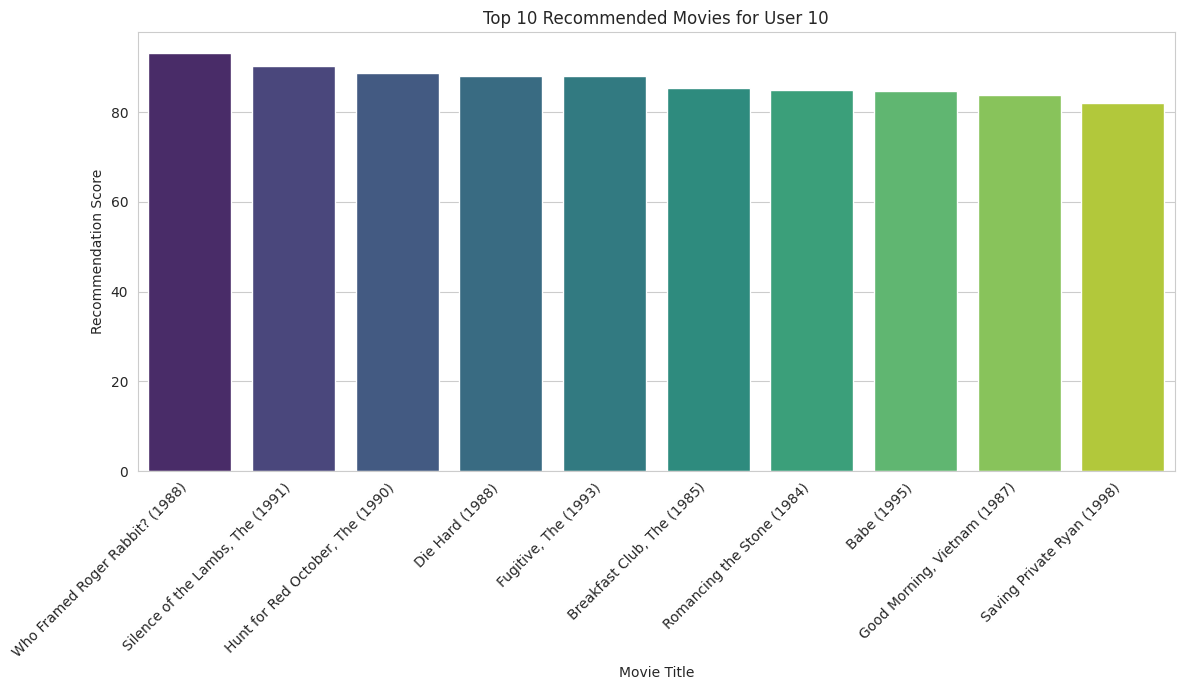

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Choose a sample user ID
sample_user_id = 10

# 3. Generate recommendations with scores
sample_recommendations = recommend_movies(sample_user_id, num_recommendations=10)

# 5. Set plot style
sns.set_style("whitegrid")

# 6. Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=sample_recommendations.index, y=sample_recommendations.values, hue=sample_recommendations.index, palette='viridis', legend=False)

# 7. Label axes and add a title
plt.xlabel('Movie Title')
plt.ylabel('Recommendation Score')
plt.title(f'Top 10 Recommended Movies for User {sample_user_id}')

# 8. Format x-axis labels
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability

# 9. Adjust layout
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# 10. Display the plot
plt.show()

## Final Task

### Subtask:
Provide a summary of the implemented Movie Recommendation System, explaining its architecture, how recommendations are generated, and the key insights gained from data analysis.


## Summary:

### Data Analysis Key Findings

*   **Dataset Overview and Preprocessing**: The MovieLens 1M dataset was successfully downloaded, extracted, and loaded into DataFrames. The `ratings.dat`, `movies.dat`, and `users.dat` files were processed. A combined `movie_ratings_df` with 1,000,209 records was created by merging ratings and movie information, and no duplicate user-movie rating entries were found.
*   **Ratings Distribution**: The distribution of movie ratings is skewed, with 4.0 being the most frequent rating (348,971 instances), followed by 3.0, and 5.0. Ratings of 1.0 were the least common (56,174 instances).
*   **Movie Popularity**: "American Beauty (1999)" is the most popular movie with 3428 ratings, closely followed by "Star Wars: Episode IV - A New Hope (1977)" with 2991 ratings.
*   **Top-Rated Movies**: After filtering for movies with at least 50 ratings to ensure statistical significance, "Sanjuro (1962)" emerged as a top-rated movie with an average rating of 4.61 from 69 ratings. "Seven Samurai (The Magnificent Seven) (Shichini...) (1954)" also showed a high average rating of 4.56 from 628 ratings.
*   **User Activity**: User rating activity varies significantly. With 6040 unique users, the average user provides approximately 165.6 ratings, but the median is 96, indicating a right-skewed distribution where many users give a few ratings, and a smaller number of highly active users contribute a large volume of ratings (up to 2314 ratings by a single user).
*   **User-Movie Rating Matrix**: A `user_movie_matrix` of shape (6040 users, 3706 movies) was successfully constructed, with unrated movies filled with $0.0$.
*   **User Similarity**: Pairwise cosine similarity between users was computed, forming a $6040 \times 6040$ `user_similarity_matrix`, where diagonal elements are $1.0$ (self-similarity) and off-diagonal elements reflect the similarity of rating patterns between different users.
*   **User-Based Collaborative Filtering System**: A `recommend_movies` function was implemented. It identifies the top 50 most similar users, aggregates their weighted movie preferences (only considering positive similarities), filters out movies already rated by the target user, and returns a list of top N recommended movie titles.
*   **System Functionality**: The recommendation system was successfully tested for multiple sample user IDs, consistently generating distinct lists of 10 movie recommendations for each user.
*   **Recommendation Visualization**: A bar chart successfully visualized the top 10 recommended movies for a sample user (User ID 10), displaying their movie titles and corresponding recommendation scores, which provides a measure of recommendation strength.

### Insights or Next Steps

*   The highly skewed distribution of user activity and ratings suggests potential biases; for instance, popular movies might receive disproportionately high ratings or more ratings, which could be addressed by incorporating regularization or alternative weighting schemes in the recommendation algorithm.
*   To improve the recommendation quality and robustness, evaluate the system using metrics such as precision, recall, or RMSE through cross-validation. Additionally, explore alternative collaborative filtering methods like item-based or matrix factorization techniques (e.g., SVD) to compare performance and potentially offer diverse recommendation strategies.
